# Сводный анализ сохранённых результатов

Этот сценарий не повторяет симуляции. Он читает CSV-файлы базового опыта,
сканирования $\beta$, миграции и карантина и строит итоговую панель.

## Загрузка рассчитанных таблиц

In [1]:
using DrWatson
@quickactivate "AgentSIRLab"
using CSV, CairoMakie, DataFrames
include(srcdir("experiment_tools.jl"))

basic = CSV.read(datadir("sir-run-basic", "trajectory.csv"), DataFrame)
beta = CSV.read(datadir("sir-scan-beta", "beta-scan-summary.csv"), DataFrame)
migration = CSV.read(datadir("sir-migration-effect", "migration-summary.csv"), DataFrame)
quarantine = CSV.read(datadir("sir-quarantine", "quarantine-summary.csv"), DataFrame)

Row,quarantine,mean_peak_fraction,mean_peak_day,mean_deaths,mean_attack_rate,mean_quarantine_days
,Bool,Float64,Float64,Float64,Float64,Float64
1,false,1.0,14.8,517.4,1.0,0.0
2,true,1.0,15.8,511.6,1.0,133.4


## Комплексная визуализация

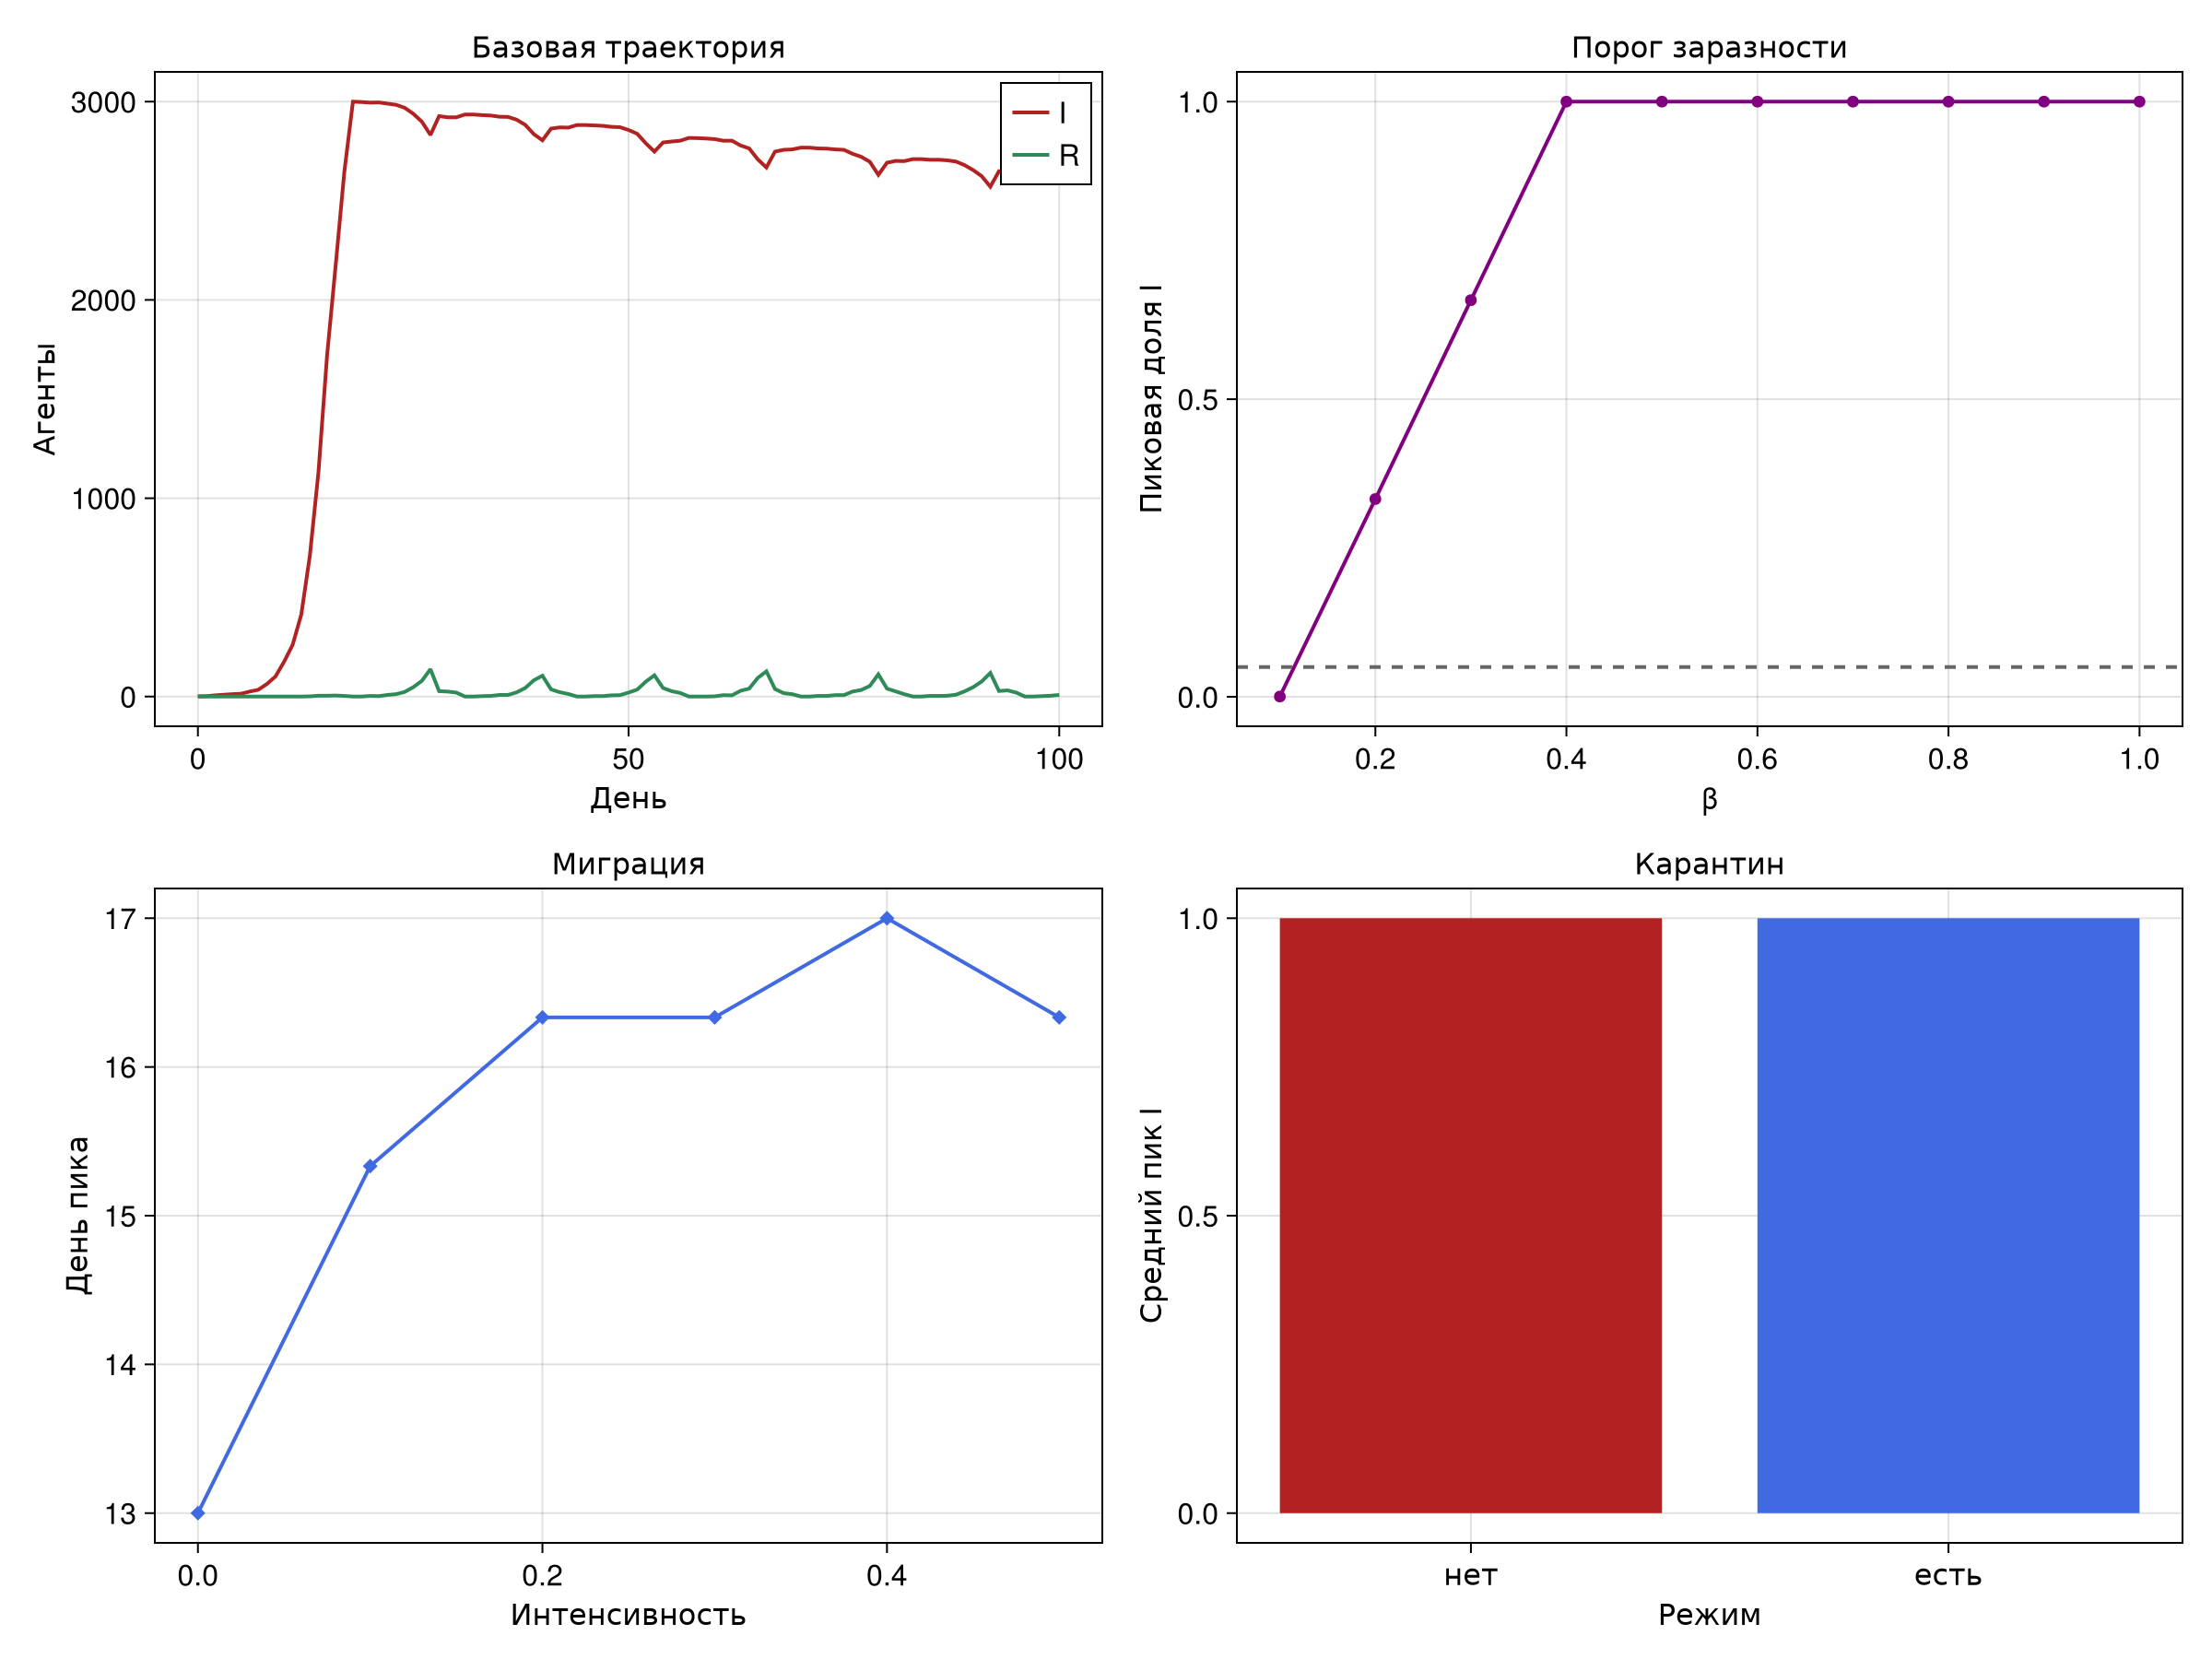

In [2]:
fig = Figure(size=(1200, 900))
ax1 = Axis(fig[1, 1], title="Базовая траектория", xlabel="День", ylabel="Агенты")
lines!(ax1, basic.time, basic.infected; color=:firebrick, label="I")
lines!(ax1, basic.time, basic.recovered; color=:seagreen, label="R")
axislegend(ax1)
ax2 = Axis(fig[1, 2], title="Порог заразности", xlabel="β", ylabel="Пиковая доля I")
scatterlines!(ax2, beta.beta, beta.mean_peak_fraction; marker=:circle, color=:purple)
hlines!(ax2, [0.05]; linestyle=:dash, color=:gray40)
ax3 = Axis(fig[2, 1], title="Миграция", xlabel="Интенсивность", ylabel="День пика")
scatterlines!(ax3, migration.migration_intensity, migration.mean_peak_day; marker=:diamond, color=:royalblue)
ax4 = Axis(fig[2, 2], title="Карантин", xlabel="Режим", ylabel="Средний пик I")
barplot!(ax4, [1, 2], quarantine.mean_peak_fraction; color=[:firebrick, :royalblue])
ax4.xticks = ([1, 2], ["нет", "есть"])
save_figure(fig, "sir-visualize-dynamics", "comprehensive-analysis.png";
            report_name="sir-comprehensive-analysis.png")

## Таблица ключевых выводов

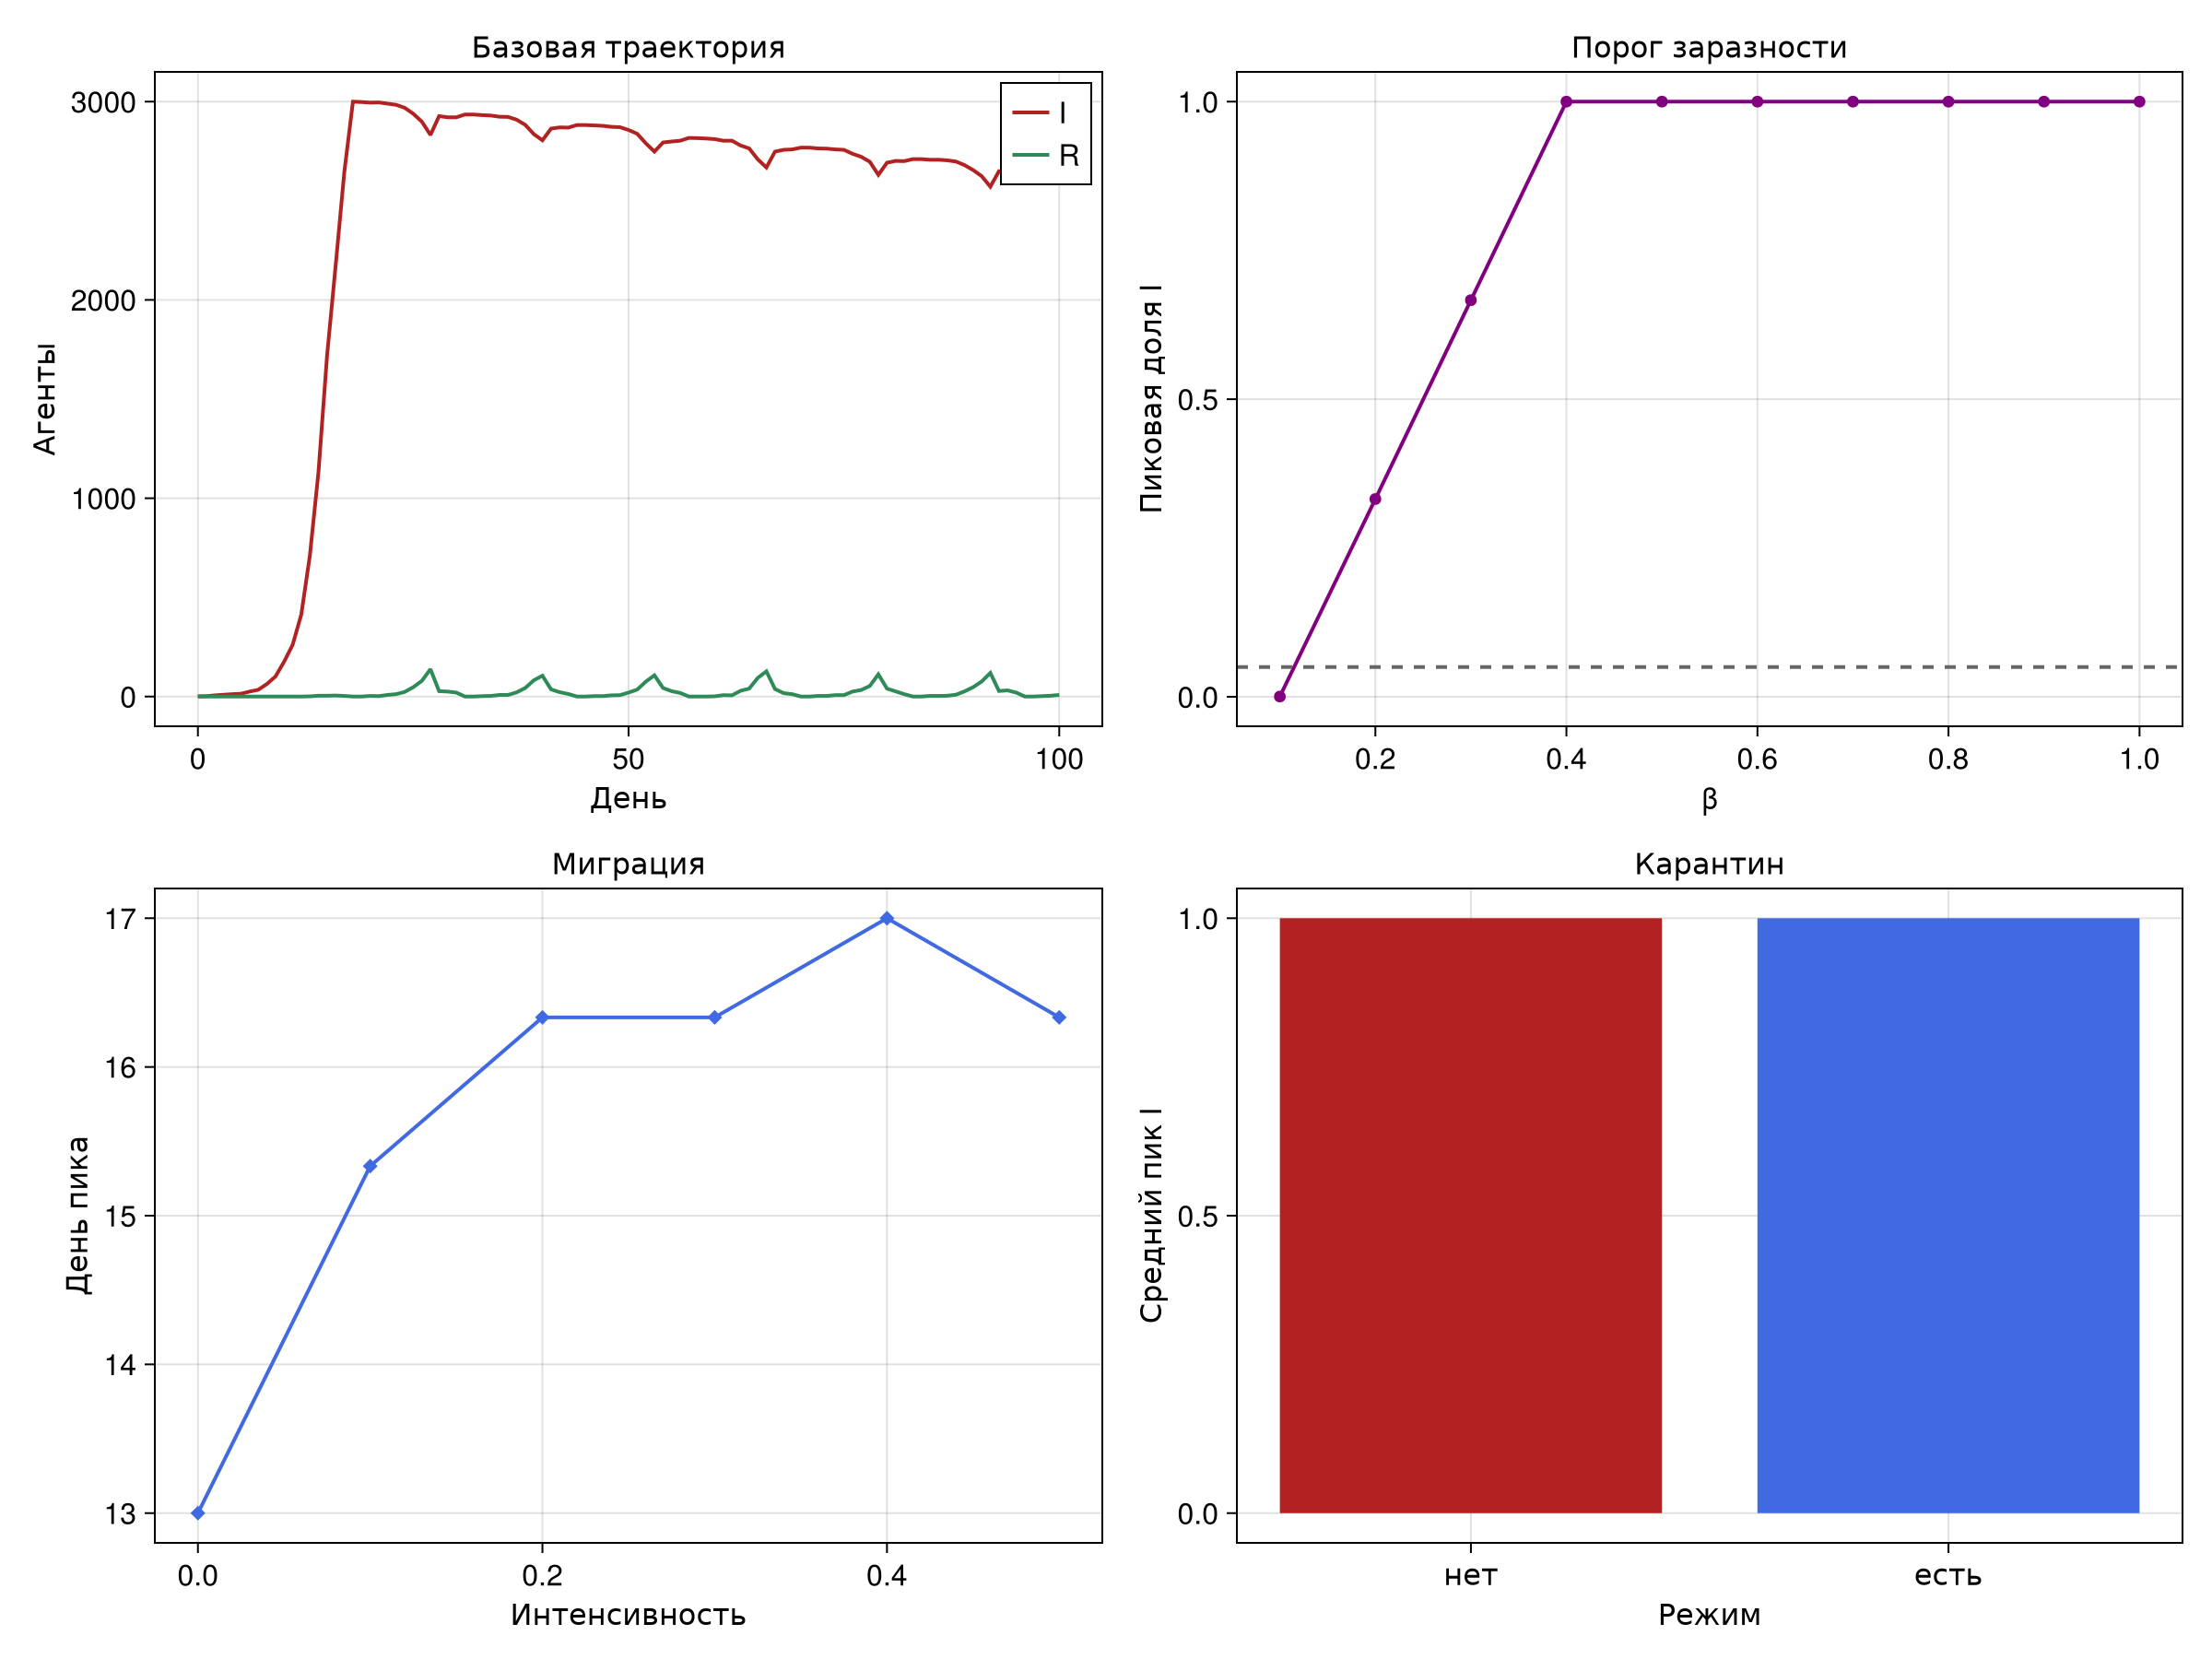

Row,indicator,value
,String,Float64
1,Базовый пик,1.0
2,Минимальный исследованный β с эпидемией,0.2
3,Минимальный средний день пика при миграции,13.0
4,Пик при карантине,1.0


In [3]:
summary = DataFrame(
    indicator=["Базовый пик", "Минимальный исследованный β с эпидемией",
               "Минимальный средний день пика при миграции", "Пик при карантине"],
    value=[maximum(basic.infected_fraction),
           minimum(beta.beta[beta.mean_peak_fraction .> 0.05]),
           minimum(migration.mean_peak_day),
           quarantine.mean_peak_fraction[quarantine.quarantine .== true][1]],
)
save_frame(summary, "sir-visualize-dynamics", "comprehensive-summary.csv")
display(fig)
summary